In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import ee
ee.Authenticate()
ee.Initialize(project = 'analog-foundry-466522-c7')

## Time series classification
TSC ( time series classification ) task involves training a model from a collection of time series ( real-valued, ordered, data) to predict a target variable. For example, we might want to build a model that can predict whether a patient is sick based on an ECG reading, or predict whether a device will fail based on some sensor reading

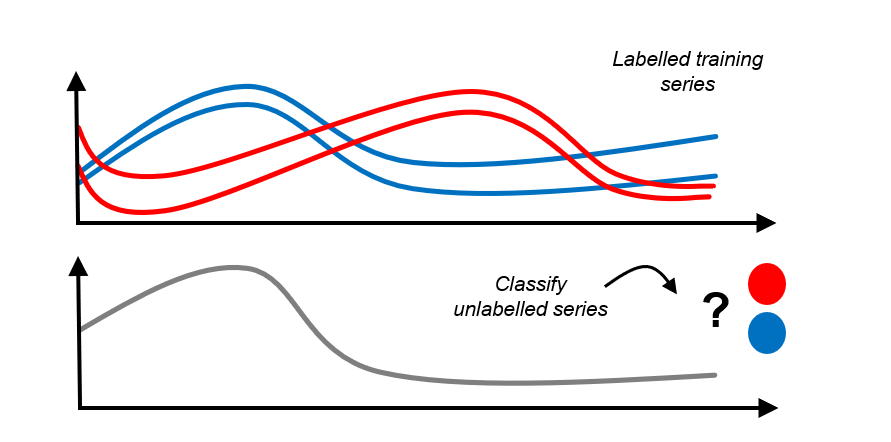

We now give a formal definition of TSC problem. Suppose we have a set of objects with same struture and a fixed set of diffrent classes. We define a dataset as a collection of(object, class) pairs, wich means that each object is associates to a now object, with the same structure as the others, the probability of belonging to the possible classes, according to the characteristics of the objects associated with each class.

A univarie time series is an ordered set of real values, while an M-dimensional multivariate time series consists of M different univarie or multivariate time series.

![image.png](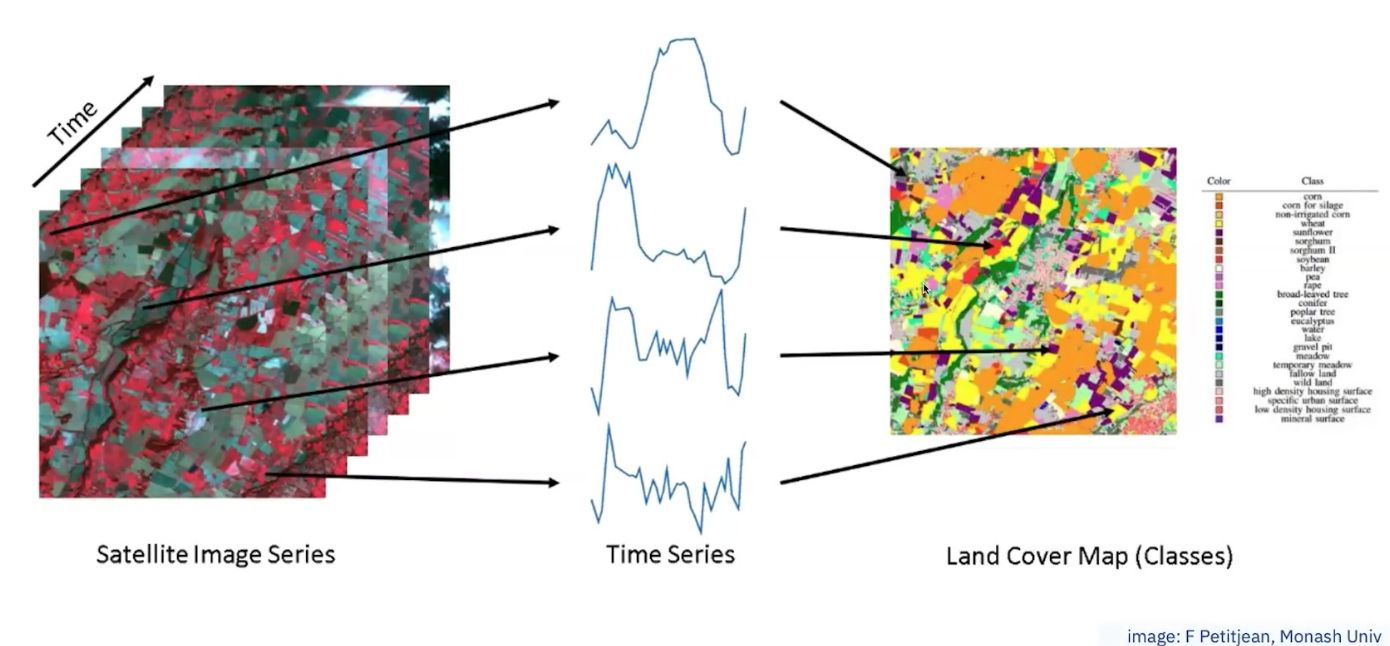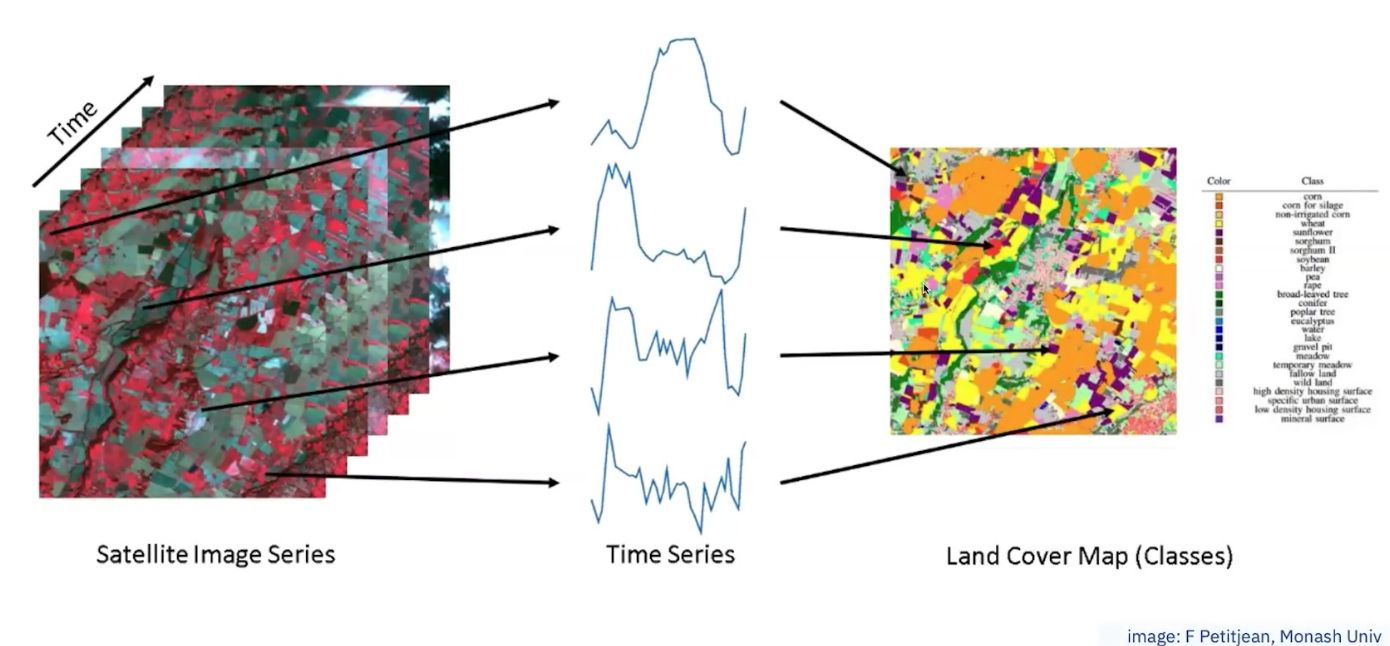)

In [3]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 82.0 MB/s eta 0:00:00


In [4]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import geopandas as gpd
import warnings
import os
import rasterio
from prophet import Prophet
warnings.filterwarnings('ignore')

In [10]:
#Criando um conjunto de pontos de diferentes crops
Class_Wine = ee.Geometry.MultiPoint([[-119.82298223898039, 36.61282934632966],
         [-119.80341284200773, 36.6125537661724],
         [-119.87791387960539, 36.61448280659136],
         [-119.80341284200773, 36.58099332673207],
         [-119.7690805666171, 36.60084069916139],
         [-119.7416147463046, 36.60993570555981],
         [-119.72307531759367, 36.611038057703475],
         [-119.72410528585539, 36.629224592987626],
         [-119.8569711916171, 36.586782670945986],
         [-119.86057608053312, 36.595328052162635],
         [-119.87207739278898, 36.60028945218614],
         [-119.88821356222257, 36.608971134508366],
         [-119.88787023946867, 36.596292793820254],
         [-119.83843176290617, 36.60759315493638],
         [-119.82195227071867, 36.60938452357907],
         [-119.80598776266203, 36.60966011506182],
         [-119.79963629171476, 36.60938452357907],
         [-119.79311315939054, 36.61062467749615],
         [-119.74264471456632, 36.60800655139306],
         [-119.66162054464445, 36.62550496889934],
         [-119.65492575094328, 36.61627401519815],
         [-119.64891760274992, 36.62206071246241],
         [-119.6394762270175, 36.627433685279705],
         [-119.61681692525968, 36.62454059261014],
         [-119.64055796058997, 36.65397596987176],
         [-119.65223093422279, 36.67600742053306],
         [-119.65961237343177, 36.67229005555964],
         [-119.66733713539466, 36.656730246079036],
         [-119.6884514847599, 36.64681439063314],
         [-119.68930979164466, 36.64392202561094],
         [-119.69325800331458, 36.64667666142838],
         [-119.69411631019935, 36.6435088217412],
         [-119.69548960121497, 36.63951440338949],
         [-119.76824834675485, 36.559245235000425],
         [-119.76807668537789, 36.553453826148214],
         [-119.76121023029977, 36.552074855302834],
         [-119.7577770027607, 36.558831577334466],
         [-119.80378225178414, 36.550695859852084],
         [-119.80601384968453, 36.549041032832655],
         [-119.81305196613961, 36.55579802011514]])
Class_Almonds = ee.Geometry.MultiPoint([[-119.83021810383492, 36.557039035190684],
         [-119.83742788166695, 36.556487475395514],
         [-119.83742788166695, 36.552074855302834],
         [-119.83742788166695, 36.55110956107087],
         [-119.85184743733102, 36.56489833447415],
         [-119.85871389240914, 36.57110247966871],
         [-119.86867025227242, 36.570551020275815],
         [-119.87210347981149, 36.572481110923626],
         [-119.87553670735055, 36.549178936437535],
         [-119.86918523640328, 36.5517990581811],
         [-119.81682851643258, 36.56310593308617],
         [-119.82094838947945, 36.5788224977055],
         [-119.7878177437275, 36.579511747497385],
         [-119.77906301350289, 36.57909819836062],
         [-119.77528646320992, 36.577719685240126],
         [-119.75829198689156, 36.57468686974122],
         [-119.7299678596943, 36.56379532315709],
         [-119.8673774617767, 36.638741811461195],
         [-119.88626021324154, 36.63819083542564],
         [-119.89552992759701, 36.63943052596441],
         [-119.89261168418881, 36.64549094809744],
         [-119.86497420249935, 36.65141317266768],
         [-119.85810774742123, 36.653065805219775],
         [-119.8563911336517, 36.666285588686094],
         [-119.84162825523373, 36.64466455497453],
         [-119.82034224449154, 36.658023490057126],
         [-119.83373183189389, 36.66559711433901],
         [-119.84214323936459, 36.62413961520817],
         [-119.73407650471735, 36.62524176428721],
         [-119.89775562764216, 36.5943756336181],
         [-119.89329243184137, 36.591481300549994],
         [-119.87406635762262, 36.58734635071557],
         [-119.8697748231988, 36.581832739667945],
         [-119.86994648457575, 36.58045427537243],
         [-119.8917474794488, 36.631578815651686],
         [-119.85844517231989, 36.62868587858294],
         [-119.86067677022028, 36.62951244311265],
         [-119.85638523579645, 36.628548116966115],
         [-119.84179401875544, 36.622624134492355],
         [-119.83750248433161, 36.62165972216027]])
Class_Cherries = ee.Geometry.MultiPoint([[-119.89157581807184, 36.556465056937334],
         [-119.89003086567926, 36.55563770962265],
         [-119.89878559590387, 36.54888070832333],
         [-119.89672565938044, 36.54915651585914],
         [-119.85140705586481, 36.59354869239014],
         [-119.84797382832575, 36.595753849304934],
         [-119.84763050557184, 36.59299739331493],
         [-119.85123539448786, 36.59272174230038],
         [-119.83329678059626, 36.582728728261316],
         [-119.8302068758111, 36.582659806431],
         [-119.78385830403376, 36.570666471155896],
         [-119.78214169026423, 36.571080065451426],
         [-119.77973843098688, 36.57149365753204],
         [-119.77870846272516, 36.57052860589851],
         [-119.76111317158747, 36.569977142407964],
         [-119.75999737263727, 36.571080065451426],
         [-119.7584524202447, 36.56956354220599],
         [-119.72187713136236, 36.59182571503345],
         [-119.72058967103521, 36.59396200944671],
         [-119.56841394348035, 36.5560169396553],
         [-119.56746980590711, 36.55546537256447],
         [-119.58266183776746, 36.595512691402895],
         [-119.58120271606336, 36.595512691402895],
         [-119.58266183776746, 36.593789912563814],
         [-119.58137437744031, 36.59358317651843],
         [-119.54197809142957, 36.587932176813325],
         [-119.54051896972547, 36.58779434238304],
         [-119.78892756676589, 36.661116232973875],
         [-119.78824092125808, 36.661116232973875],
         [-119.8398251650325, 36.62558053204331],
         [-119.83785105919753, 36.62558053204331],
         [-119.83750773644363, 36.62440950327035],
         [-119.83888102745925, 36.624202849287144],
         [-119.83973933434402, 36.624202849287144],
         [-119.83699275231277, 36.6240650796572],
         [-119.79922724938308, 36.62599383206842],
         [-119.79854060387527, 36.62613159825094],
         [-119.79931308007156, 36.62468504105281],
         [-119.79854060387527, 36.62482280957467],
         [-119.79888392662917, 36.62385842475059]])
Class_Citrus = ee.Geometry.MultiPoint([[-119.69358809714616, 36.6652603648613],
         [-119.68929656272233, 36.66594884222072],
         [-119.68620665793718, 36.66691270017729],
         [-119.68534835105241, 36.66484727548946],
         [-119.67127211814226, 36.6729709594935],
         [-119.66680892234147, 36.67200717741508],
         [-119.66595061545671, 36.67710131738032],
         [-119.67831023459733, 36.67613758703974],
         [-119.68860991721452, 36.675311522853484],
         [-119.68431838279069, 36.6757245560553],
         [-119.69393141990007, 36.67283327707854],
         [-119.69650634055436, 36.67710131738032],
         [-119.69375975852311, 36.68233278571631],
         [-119.69255812888444, 36.680818449891404],
         [-119.69341643576921, 36.691005225635045],
         [-119.69530471091569, 36.69788741834709],
         [-119.66165908103288, 36.696235748280706],
         [-119.65959914450944, 36.694721686213605],
         [-119.657539207986, 36.69719922679858],
         [-119.65444930320085, 36.69788741834709],
         [-119.64964278464616, 36.695547541946574],
         [-119.64998610740007, 36.69403346632616],
         [-119.62252028708757, 36.658650668864],
         [-119.61943038230241, 36.65947691190202],
         [-119.61977370505632, 36.657686707444974],
         [-119.61668380027116, 36.65754899768551],
         [-119.61634047751726, 36.65396845747989],
         [-119.60466750388444, 36.66498497219307],
         [-119.59780104880632, 36.66484727548946],
         [-119.60037596946061, 36.66828961917539],
         [-119.60037596946061, 36.6655357565441],
         [-119.59574111228288, 36.66815192838417],
         [-119.60501082663835, 36.62352714349036],
         [-119.60707076316179, 36.62214942403314],
         [-119.58921797995866, 36.63069088772247],
         [-119.58372481589616, 36.63041537141072],
         [-119.57960494284929, 36.63013985411392],
         [-119.57067855124772, 36.628486729647825],
         [-119.56140883689226, 36.62821120545593],
         [-119.52707656150163, 36.602307533766435]])
Class_Alfalfa = ee.Geometry.MultiPoint([[-119.49358547717651, 36.70314585101399],
         [-119.49264133960327, 36.702044816902315],
         [-119.4947012761267, 36.70004915237429],
         [-119.49573124438842, 36.70225126199967],
         [-119.49598873645385, 36.69812225470046],
         [-119.49779118091186, 36.69626412905685],
         [-119.4987353184851, 36.694199492334796],
         [-119.49804867297729, 36.69296068368799],
         [-119.49573124438842, 36.69268539016698],
         [-119.49452961474975, 36.697846979661264],
         [-119.49246967822631, 36.69977388423524],
         [-119.49135387927612, 36.69819107330622],
         [-119.48251331836303, 36.69970506704646],
         [-119.48216999560913, 36.70465974716411],
         [-119.48311413318237, 36.69598884736411],
         [-119.48165501147827, 36.69887925597554],
         [-119.50783337146362, 36.69413067015585],
         [-119.50783337146362, 36.69585120614808],
         [-119.50869167834838, 36.693442444977975],
         [-119.58702744324405, 36.64591439129269],
         [-119.5865124591132, 36.64426160526685],
         [-119.585396660163, 36.64563892941801],
         [-119.58548249085148, 36.64371066871017],
         [-119.58659828980167, 36.64343519895408],
         [-119.5894307025214, 36.649839615958825],
         [-119.58737076599796, 36.649908477763766],
         [-119.58599747498234, 36.649908477763766],
         [-119.58857239563663, 36.64970189216424],
         [-119.58471001465519, 36.64481253788284],
         [-119.58479584534366, 36.64343519895408],
         [-119.4993900760629, 36.69315967458978],
         [-119.49814553107998, 36.69205849744163],
         [-119.49621434058926, 36.69216173346922],
         [-119.49494873578573, 36.696488440446814],
         [-119.4955924659493, 36.70154655132576],
         [-119.49400459821248, 36.701856220771276],
         [-119.48207413251424, 36.70130569645003],
         [-119.48138748700643, 36.700411086018306],
         [-119.48945557172323, 36.69321941623659],
         [-119.48906933362508, 36.69235912360564]])

In [8]:
import geemap
import ee

Map = geemap.Map(center=[36.6, -119.8], zoom=10)

# Add the USDA Cropland Data Layer
usda_crop = ee.ImageCollection('USDA/NASS/CDL') \
    .filterDate('2021-01-01', '2021-12-31') \
    .mosaic().select('cropland')

vis_params = {
    'min': 1,
    'max': 254,
    'palette': ['006400', 'ffbb22', 'ffff4c', 'f096ff', 'fa0000', 'b4b4b4',
                'f0f0f0', '0064c8', '0096a0', '00cf75', 'fae6a0', '008000',
                '00cf00', 'a0d000', 'ffff00', 'a0a0a0', '000080', '800080',
                'a00000', 'ffa0a0', 'a0ffa0', '00ffff', '008080', '0000ff',
                '0000bc', '8080ff', 'c8c8c8', '800000']
}
Map.addLayer(usda_crop, vis_params, 'USDA Cropland Data Layer')


# Function to plot points by class
def plot_points_by_class(geometry, class_name):
    style = {'color': 'black', 'fillColor': '', 'radius': 3}
    if class_name == 'Wine':
      style['fillColor'] = 'blue'
    elif class_name == 'Almonds':
      style['fillColor'] = 'red'
    elif class_name == 'Cherries':
      style['fillColor'] = 'green'
    elif class_name == 'Citrus':
      style['fillColor'] = 'yellow'
    elif class_name == 'Alfafa':
      style['fillColor'] = 'purple'

    Map.addLayer(geometry, style, class_name)


# Plot the points for each class
plot_points_by_class(Class_Wine, 'Wine')
plot_points_by_class(Class_Almonds, 'Almonds')
plot_points_by_class(Class_Cherries, 'Cherries')
plot_points_by_class(Class_Citrus, 'Citrus')
plot_points_by_class(Class_Alfalfa, 'Alfafa')

# Display the map
Map


Map(center=[36.6, -119.8], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [12]:
#Transformando todos os pontos em uma unica feature collection
feature_collection = ee.FeatureCollection([
    ee.Feature(Class_Wine, {'Class': 'Wine'}),
    ee.Feature(Class_Almonds, {'Class': 'Almonds'}),
    ee.Feature(Class_Cherries, {'Class': 'Cherries'}),
    ee.Feature(Class_Citrus, {'Class': 'Citrus'}),
    ee.Feature(Class_Alfalfa, {'Class': 'Alfafa'})

])

In [13]:
display(feature_collection)

In [14]:
def multipoint_to_points(feature):
  multipoint = feature.geometry()
  class_name = feature.get('Class')
  #Get coordinates of the MultiPoints
  coords = multipoint.coordinates()
  #Create a list of Features from coordinates
  features = coords.map(lambda coord: ee.Feature(ee.Geometry.Point(coord)).set('Class', class_name))
  #Return a FeatureCOllection dos pontos individuais
  return ee.FeatureCollection(features)

point_features = feature_collection.map(multipoint_to_points).flatten()

In [19]:
def addNDVI(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

def extract_ndvi_timeseries(feature):
    point = feature.geometry()
    class_id = feature.get('Class').getInfo()

    s2_sr_harmonized = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterBounds(point) \
        .filterDate('2023-01-01', '2023-12-31') \
        .map(addNDVI)

    months = ee.List.sequence(1, 12)
    years = ee.List.sequence(2023, 2023)

    def monthly(collection):
      img_coll = ee.ImageCollection([])
      for y in years.getInfo():
        for m in months.getInfo():
          filtered = collection.filter(ee.Filter.calendarRange(y, y, 'year')).filter(ee.Filter.calendarRange(m, m, 'month'))
          filtered = filtered.median()
          img_coll = img_coll.merge(filtered.set('year', y).set('month', m).set('system:time_start', ee.Date.fromYMD(y, m, 1).format('YYYY-MM-dd').getInfo()))
          img_coll = img_coll.select('NDVI')
      return img_coll

    monthly_s2_collection = monthly(s2_sr_harmonized)

    ndvi_timeseries = monthly_s2_collection.select('NDVI') \
        .getRegion(point, 30) \
        .getInfo()

    class_list.append(class_id)
    df = pd.DataFrame(ndvi_timeseries[1:], columns=ndvi_timeseries[0])
    df['date'] = df['time']
    df = df.set_index('date')
    df = df[['NDVI']]
    return df

dfs = []
class_list = []


for feature in point_features.getInfo()['features']:
  dfs.append(extract_ndvi_timeseries(ee.Feature(feature)))

In [21]:
#Convertendo em um dataframe
ndvi_df = pd.concat(dfs, axis = 1)
ndvi_df = ndvi_df.T.reset_index(drop = True)
ndvi_df['Classe'] = class_list
ndvi_df

date,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,Classe
0,0.318135,0.198323,0.197208,0.177967,0.344116,0.426382,0.463539,0.461427,0.387629,0.390594,0.410534,0.132949,Wine
1,0.211793,0.158740,0.153425,0.197292,0.272719,0.330481,0.332641,0.322678,0.317642,0.319405,0.338962,0.131536,Wine
2,0.298569,0.194311,0.154483,0.146479,0.407806,0.452722,0.480268,0.433181,0.396530,0.352444,0.341321,0.135538,Wine
3,0.443601,0.439508,0.522739,0.650218,0.456934,0.451865,0.419228,0.442965,0.417468,0.378019,0.447969,0.142990,Wine
4,0.209651,0.137768,0.153815,0.151413,0.419170,0.500637,0.484049,0.496346,0.436896,0.421362,0.397918,0.117573,Wine
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.589531,0.629662,0.764611,0.899719,0.719161,0.555190,0.753784,0.783859,0.779925,0.761384,0.631900,0.234833,Alfafa
196,0.836447,0.714871,0.624605,0.568544,0.624511,0.570010,0.723826,0.587678,0.468084,0.792641,0.826952,0.203638,Alfafa
197,0.843162,0.726048,0.683235,0.631695,0.588760,0.547373,0.651241,0.605400,0.501459,0.810821,0.824391,0.201896,Alfafa
198,0.429343,0.432568,0.439226,0.612217,0.815699,0.635619,0.799945,0.834310,0.776933,0.703830,0.456139,0.163859,Alfafa


In [22]:
import matplotlib.pyplot as plt

class_colors = {
    'Wine': 'blue',
    'Almonds': 'red',
    'Cherries': 'green',
    'Citrus': 'yellow',
    'Alfalfa': 'purple'
}

# Plot time series for 5 points of each class
plt.figure(figsize=(12, 6))
for class_name in ndvi_df['classe'].unique():
    class_df = ndvi_df[ndvi_df['classe'] == class_name].head(5)
    class_df = class_df.drop(columns='classe')
     # Select first 5 points
    for index, row in class_df.iterrows():
        # The change is on this line. Use row.index[:-1] to select the same columns as row.values[:-1]
        plt.plot(row.index[:-1], row.values[:-1], label=class_name, color=class_colors[class_name])

plt.xlabel('Time')
plt.ylabel('NDVI')
plt.title('NDVI Time Series for 5 Points per Class')
plt.legend()
plt.show()


KeyError: 'classe'

<Figure size 1200x600 with 0 Axes>

In [23]:
#Convertendo em um dataframe
ndvi_df = pd.concat(dfs, axis = 1)
ndvi_df = ndvi_df.T.reset_index(drop = True)
ndvi_df['Classe'] = class_list
ndvi_df

date,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,Classe
0,0.318135,0.198323,0.197208,0.177967,0.344116,0.426382,0.463539,0.461427,0.387629,0.390594,0.410534,0.132949,Wine
1,0.211793,0.158740,0.153425,0.197292,0.272719,0.330481,0.332641,0.322678,0.317642,0.319405,0.338962,0.131536,Wine
2,0.298569,0.194311,0.154483,0.146479,0.407806,0.452722,0.480268,0.433181,0.396530,0.352444,0.341321,0.135538,Wine
3,0.443601,0.439508,0.522739,0.650218,0.456934,0.451865,0.419228,0.442965,0.417468,0.378019,0.447969,0.142990,Wine
4,0.209651,0.137768,0.153815,0.151413,0.419170,0.500637,0.484049,0.496346,0.436896,0.421362,0.397918,0.117573,Wine
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.589531,0.629662,0.764611,0.899719,0.719161,0.555190,0.753784,0.783859,0.779925,0.761384,0.631900,0.234833,Alfafa
196,0.836447,0.714871,0.624605,0.568544,0.624511,0.570010,0.723826,0.587678,0.468084,0.792641,0.826952,0.203638,Alfafa
197,0.843162,0.726048,0.683235,0.631695,0.588760,0.547373,0.651241,0.605400,0.501459,0.810821,0.824391,0.201896,Alfafa
198,0.429343,0.432568,0.439226,0.612217,0.815699,0.635619,0.799945,0.834310,0.776933,0.703830,0.456139,0.163859,Alfafa


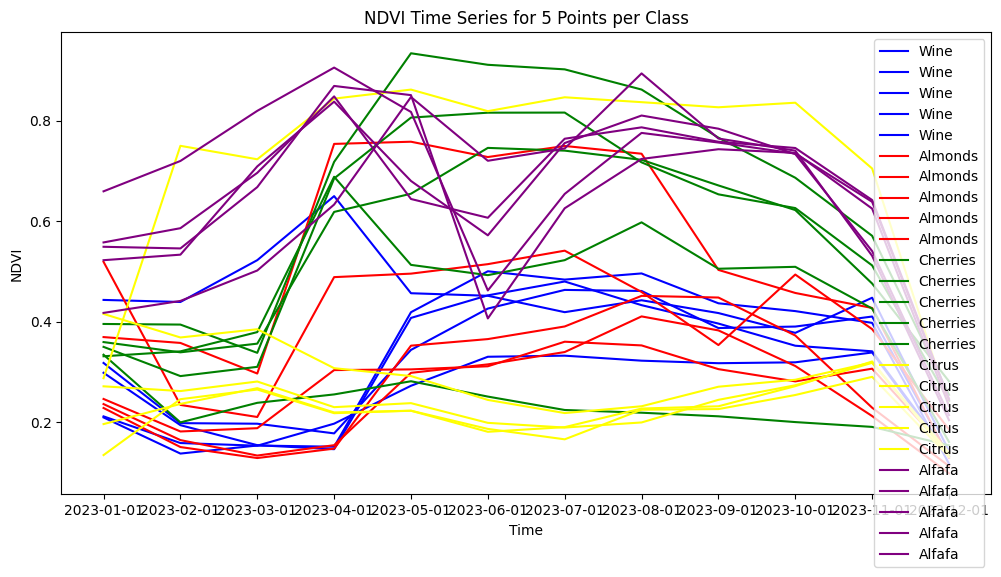

In [25]:
import matplotlib.pyplot as plt

class_colors = {
    'Wine': 'blue',
    'Almonds': 'red',
    'Cherries': 'green',
    'Citrus': 'yellow',
    'Alfafa': 'purple'
}

# Plot time series for 5 points of each class
plt.figure(figsize=(12, 6))
for class_name in ndvi_df['Classe'].unique():
    class_df = ndvi_df[ndvi_df['Classe'] == class_name].head(5)
    class_df = class_df.drop(columns='Classe')
     # Select first 5 points
    for index, row in class_df.iterrows():
        plt.plot(row.index, row.values, label=class_name, color=class_colors[class_name])

plt.xlabel('Time')
plt.ylabel('NDVI')
plt.title('NDVI Time Series for 5 Points per Class')
plt.legend()
plt.show()

## Algorithms used
Many different categories of algorithsm have been investigated to deal with timeseries classification. To compare time series, specific metrics and kernels have been proposed. Some algorithms consist of extracting features from time series that can be used as input to a standasrd machine learning classififer, while other algorithms works on raw time series. Bag-of-words molds that rely on discretized time series are popular, with many algorithms being developed. Transforming time series int oimagescan also be studied.

### Standard classifiers

We canc use SKLEARNS default classifiers, sucj as RandomForest

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [28]:
ndvi_df

date,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,Classe
0,0.318135,0.198323,0.197208,0.177967,0.344116,0.426382,0.463539,0.461427,0.387629,0.390594,0.410534,0.132949,Wine
1,0.211793,0.158740,0.153425,0.197292,0.272719,0.330481,0.332641,0.322678,0.317642,0.319405,0.338962,0.131536,Wine
2,0.298569,0.194311,0.154483,0.146479,0.407806,0.452722,0.480268,0.433181,0.396530,0.352444,0.341321,0.135538,Wine
3,0.443601,0.439508,0.522739,0.650218,0.456934,0.451865,0.419228,0.442965,0.417468,0.378019,0.447969,0.142990,Wine
4,0.209651,0.137768,0.153815,0.151413,0.419170,0.500637,0.484049,0.496346,0.436896,0.421362,0.397918,0.117573,Wine
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.589531,0.629662,0.764611,0.899719,0.719161,0.555190,0.753784,0.783859,0.779925,0.761384,0.631900,0.234833,Alfafa
196,0.836447,0.714871,0.624605,0.568544,0.624511,0.570010,0.723826,0.587678,0.468084,0.792641,0.826952,0.203638,Alfafa
197,0.843162,0.726048,0.683235,0.631695,0.588760,0.547373,0.651241,0.605400,0.501459,0.810821,0.824391,0.201896,Alfafa
198,0.429343,0.432568,0.439226,0.612217,0.815699,0.635619,0.799945,0.834310,0.776933,0.703830,0.456139,0.163859,Alfafa


In [30]:
#Vamos usar as features separadando os dados
X = ndvi_df.drop('Classe',axis = 1)
y = ndvi_df['Classe']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 12)
(40, 12)
(160,)
(40,)


In [31]:
#We can then obtain the accuracy on the test data:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

classifier = RandomForestClassifier(n_estimators=100)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

accuracy_score(y_test, y_pred)

0.7

## KNN with DTW

Nearest neighbor methods are one of the most intuitive algorithms for supervised learning: the prediction for a new sample is based on the target value of similar samples. A key element of nearest neighbor algorithms is the metric, i.e. the mathematical function that defines the (dis)similarity between any pair of samples.

Although Euclidean distance is the most common metric, it is not suitable for comparing time series for two main reasons: (i) it is defined only for two vectors of the same length, while time series in a given dataset are usually of different lengths, and (ii) it compares the values ​​of both time series at each time point independently, while the values ​​of the time series are correlated. Considering the minimum of the Euclidean distances between the smaller time series and the same-length subsequences of the larger time series may not be optimal. A concrete example from automatic speech recognition is considering a given sentence, with one being pronounced more slowly than the other. Not only will the corresponding time series have different lengths, but the Euclidean distance between the smaller time series and any same-length subsequence with consecutive time points of the larger time series will not be small, even if the same sentence was uttered and a relevant metric should yield a small value. Another concrete example could consist of sequences of geolocations, with several people walking on the same route, but at different speeds.

Dynamic temporal warping (DTW) is a metric for time series that addresses both limitations of Euclidean distance [9]. The nearest neighbor classifier with the DTW metric is often considered the baseline algorithm for time series classification.

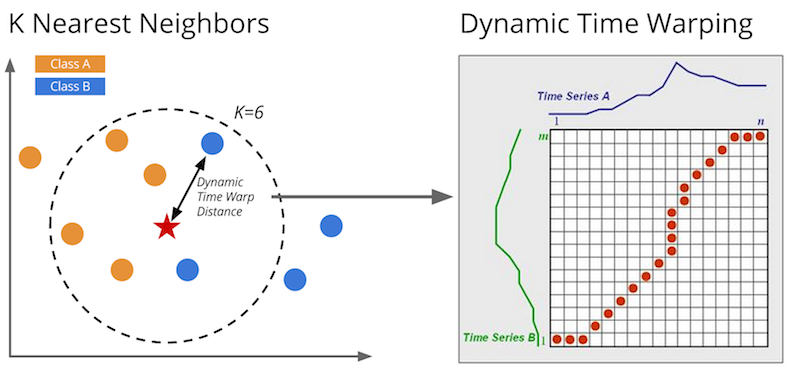

In [32]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 6.2 MB/s eta 0:00:00


In [33]:
from tslearn.metrics import dtw
from sklearn.neighbors import KNeighborsClassifier
from tslearn.utils import to_time_series_dataset
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

In [34]:
clf = KNeighborsClassifier(n_neighbors=3, metric = dtw)

In [35]:
clf.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_score(y_test, y_pred)

0.7

In [36]:
# To use knn for time series, we need to convert the original dataframe to be compatible with the tslieanr library
X_tslearn = to_time_series_dataset(X)
X_train, X_test, y_train, y_test = train_test_split(X_tslearn, y, test_size=0.2, random_state=42)

In [37]:
knn = KNeighborsTimeSeriesClassifier(n_neighbors=3,
                           metric="dtw")
knn.fit(X_train,y_train)

KNeighborsTimeSeriesClassifier(n_neighbors=3)

In [38]:
y_pred = knn.predict(X_test)
accuracy_score(y_test, y_pred)

0.725

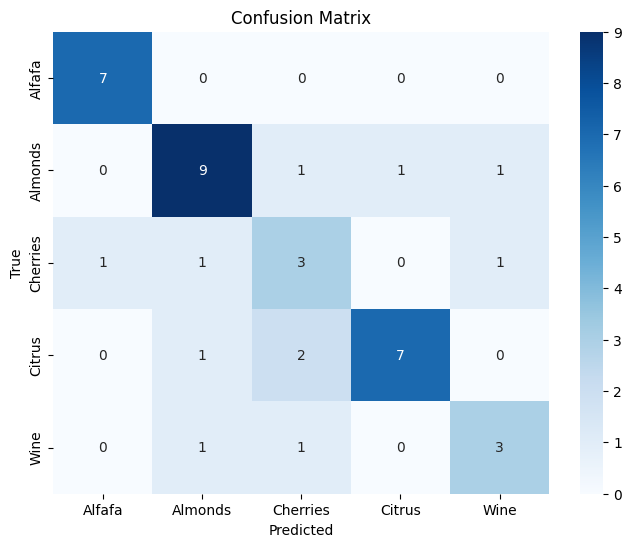

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## Shapelets

A shapelet is define as a subsequence of consecutive obserations of a time series. In some use cases, specific shapelets may be characteristic of classes and thu useful for discrimating between them. Several algorithms rely on shapelets, eigher by extracting the best shapelets from the training dataset ro bt learning them directly

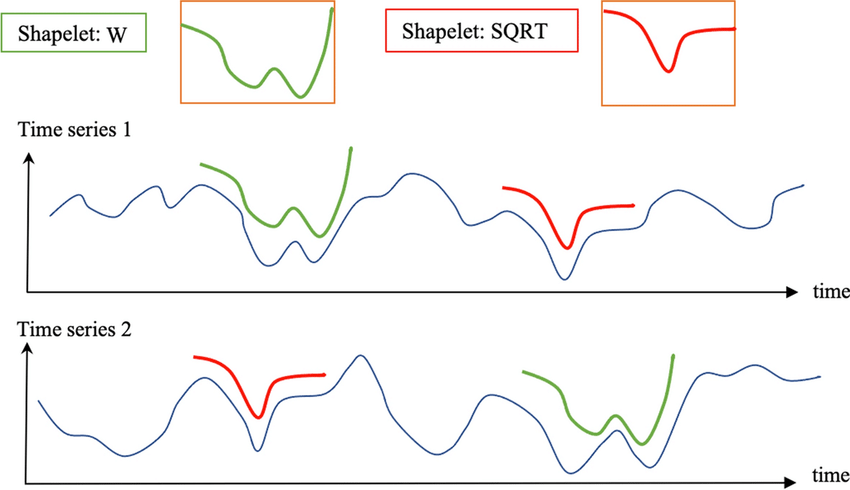

## Shapelet Extraction

The algorithm extracts all shapelets whose length falls within a range, where range is a hyperparameter of the algorithm, and selects the k best shapelets, where k is another hyperparameter of the algorithm. This process can be thought of as univariate feature extraction, where each feature is the distance between a given shapelet and all time series in the dataset. Shapelets are classified based on the F-statistic from the analysis of variance test that compares between- and within-class variability. To extract features (i.e., shapelets) that are not highly correlated, self-similar shapelets are removed, with any pair of shapelets being considered self-similar if they are from the same time series and have any overlapping indices.

Once the k best shapelets have been identified and corresponding features generated, any standard machine learning classifier can be applied to this new dataset.

## Leaning shapelets
To addres the limitations of the Shapelet Transform algorithm, another algorithm that relies on learning shapelets rather than extracting them was proposed;

The distnace between a shapelet and a time series depends on the minimum function, which is not differenciable. Similar to the soft-DTW variant of DTW, the minimum function is derived from a soft minimum function, namely the LogSumExp function, which is differentiable. The logistic regression algorithm is used as the machine leaning classifer built on top of the transofmation. The image below illustrates learning shapelets and the distances betweeen both shapeletes and time series ,highlighting that each shpalet is class-specific.

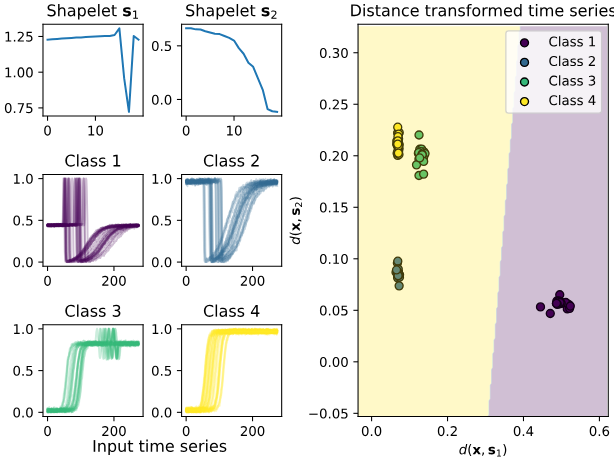

Since the transformation and classification functions are differentiable, the chain rule allows us to compute the gradients of the objection function with respect to shapelets and the logistic regression coefficients, respectively, thus minimizing the objective function that can be attempted to be solved by gradient descent.

Learning shapelets rather than extracting them has several advantages. First, it can lead to shapelets that are not from the dataset but are discriminative of the classes. Second, it does not require traversing the entire dataset and can therefore be faster to train, especially with stochastic variants of gradient descent.

However, learning shapelets also has drawbacks. Since both the shapelets and the logistic regression coefficients need to be learned, the objective function is not convex (one can see the analogy with some clustering algorithms, such as k-means and Gaussian mixture models, where both the parameters and the cluster memberships need to be learned). Therefore, the optimization algorithm may converge to a poor local minimum. This also leads to more hyperparameters, since the optimization process is a key component of the algorithm. Finally, since learning shapelets is embedded in the algorithm, it may not be optimal to try other classifiers besides logistic regression later, whereas the Shapelet Transform algorithm is independent of the machine learning classifier, and therefore the transformation step can be computed only once and many classifiers can be built on top of it to find the best performing classifier.

In [40]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.7/145.7 kB 13.0 MB/s eta 0:00:00


In [41]:
from sktime.classification.shapelet_based import ShapeletTransformClassifier
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam
from tslearn.shapelets import LearningShapelets

In [42]:
X_tslearn = TimeSeriesScalerMinMax().fit_transform(X_tslearn)
X_train, X_test, y_train, y_test = train_test_split(X_tslearn, y, test_size=0.2, random_state=42)
shapelet_sizes = {12: 4}

# Define the model and fit it using the training data
shp_clf = LearningShapelets(n_shapelets_per_size=shapelet_sizes,
                            weight_regularizer=0.0001,
                            optimizer=Adam(learning_rate=0.01),
                            max_iter=500,
                            verbose=1,
                            scale=False,
                            random_state=42)
shp_clf.fit(X_train, y_train)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - categorical_accuracy: 0.2125 - categorical_crossentropy: 1.6168 - loss: 1.6172
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step - categorical_accuracy: 0.2125 - categorical_crossentropy: 1.6135 - loss: 1.6139
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - categorical_accuracy: 0.1875 - categorical_crossentropy: 1.6104 - loss: 1.6108
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - categorical_accuracy: 0.1187 - categorical_crossentropy: 1.6074 - loss: 1.6078
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - categorical_accuracy: 0.1562 - categorical_crossentropy: 1.6045 - loss: 1.6049
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - categorical_accuracy: 0.1875 - categorical_crossentropy: 1.6018 - loss: 1.6022
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - categorical_accuracy: 0.1937 - categorical_crossentropy: 1.5992 - loss: 1.5996
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - categorical_accuracy: 0.1937 - c

LearningShapelets(max_iter=500, n_shapelets_per_size={12: 4},
                  optimizer=<keras.src.optimizers.adam.Adam object at 0x794f1cf097c0>,
                  random_state=42, verbose=1, weight_regularizer=0.0001)

In [43]:
y_pred = shp_clf.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step


In [44]:
accuracy_score(y_test, y_pred)

0.675

## Tree-Based Algorithms

One of the first algorithms proposed based on the random forest algorithm is called time series forest and is relatively simple. The algorithm considers information from subsequences of the time series. Given a minimum length for the subsequences, which is a hyperparameter, random intervals are generated, with the start indices, end indices, and lengths of all intervals being all randomly generated. For a given time series and a given interval, the corresponding subsequence is the ordered set of time series values ​​belonging to the interval. From each subsequence, three features are extracted: the mean, the standard deviation, and the slope.

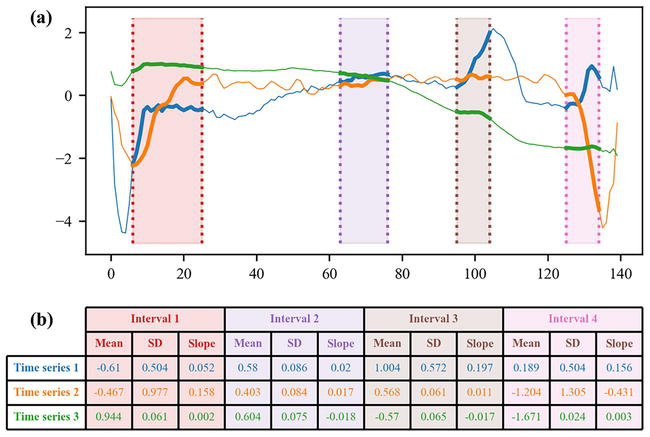

The total number of extracted features is therefore three times the number of intervals considered. A random forest classifier is then trained on these extracted features. Predictions for new time series are obtained in the same way: Given the intervals already generated, the three features are extracted from each subsequence, then the fine-tuned random forest classifier outputs its prediction.

In [45]:
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sktime.datatypes import convert_to
from tslearn.utils import to_sktime_dataset

In [46]:
X_tslearn

array([[[0.56016794],
        [0.19774976],
        [0.19437814],
        ...,
        [0.77934989],
        [0.83966603],
        [0.        ]],

       [[0.38691803],
        [0.13115141],
        [0.10552584],
        ...,
        [0.90571484],
        [1.        ],
        [0.        ]],

       [[0.47292447],
        [0.17048933],
        [0.05495575],
        ...,
        [0.62920496],
        [0.59693899],
        [0.        ]],

       ...,

       [[1.        ],
        [0.81737066],
        [0.75060702],
        ...,
        [0.94956674],
        [0.97072887],
        [0.        ]],

       [[0.39597845],
        [0.40078793],
        [0.4107188 ],
        ...,
        [0.80538484],
        [0.43594478],
        [0.        ]],

       [[0.43197303],
        [0.32379134],
        [0.45167663],
        ...,
        [0.78827886],
        [0.4014598 ],
        [0.        ]]])

In [47]:
X_sktime = convert_to(X_tslearn, to_type="pd-multiindex")
X_sktime = to_sktime_dataset(X_tslearn)
X_sktime

,dim_0
0,0 0.560168 1 0.197750 2 0.194378 3...
1,0 0.386918 1 0.131151 2 0.105526 3...
2,0 0.472924 1 0.170489 2 0.054956 3...
3,0 0.592654 1 0.584585 2 0.748674 3...
4,0 0.240373 1 0.052718 2 0.094610 3...
...,...
195,0 0.533472 1 0.593830 2 0.796796 3...
196,0 1.000000 1 0.807879 2 0.665236 3...
197,0 1.000000 1 0.817371 2 0.750607 3...
198,0 0.395978 1 0.400788 2 0.410719 3...


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_sktime, y, test_size=0.2, random_state=42)
clf = TimeSeriesForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

TimeSeriesForestClassifier(n_estimators=100)

In [49]:
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.8

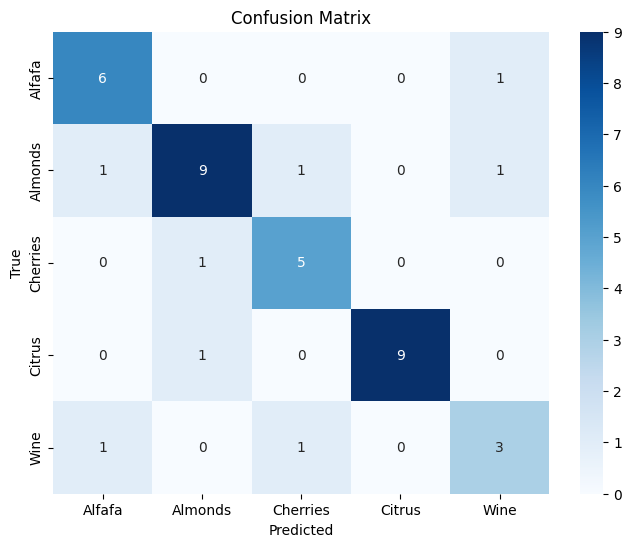

In [50]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

##Random Convolutional Kernel Transform (ROCKET)


This algorithm extracts features from time series using a large number of random convolutional kernels, meaning that all parameters of all kernels (length, weights, bias, dilation, and padding) are randomly generated from fixed distributions. Instead of extracting a single feature for each kernel, such as the maximum or the mean, as is typically done in convolutional neural networks, two features are extracted: the maximum and the proportion of positive values.
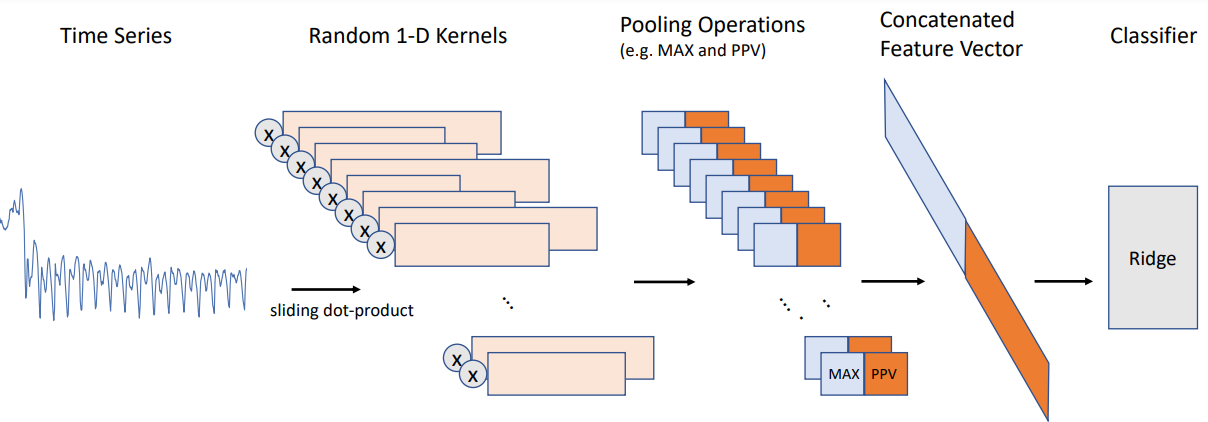


The classifier built on top of the transformation is responsible for selecting the most relevant features to perform the classification. A ridge regression classifier was originally proposed for several reasons.

- First, it is highly efficient when the number of classes is large, because the multi-class classification task is treated as a multi-output regression task, with the predicted class corresponding to the output with the highest value; therefore, the projection matrix needs to be computed only once.

- Second, optimizing the λ parameter (controlling the amount of regularization) using leave-one-out cross-validation is also highly efficient. Logistic regression was used for datasets in which the number of training time series was much larger than the number of extracted time series due to the better scalability of logistic regression solved with stochastic gradient descent to large numbers of training samples.

The ROCKET algorithm combined with a linear classifier has a much lower computational complexity than the best performing time series classification algorithms, although it performs comparably. Its reported performance is actually higher on average than that of convolutional neural networks on commonly compared datasets. Given its high predictive performance and low computational time, ROCKET is one of the most prominent transformation algorithms for time series classification.

Several recent extensions have been proposed. MiniROCKET reduces the randomness of kernel parameters by using a fixed value or sampling from smaller distributions. Furthermore, it extracts only the proportion of positive values ​​for each kernel. These modifications also allow for more optimization and lead to much lower computational complexity while maintaining similar performance. MultiROCKET extends MiniROCKET by extracting possibly multiple features, leading to slightly higher computational time but better accuracy. In particular, the authors found that the proportion of positive values ​​and the longest period of consecutive positive values ​​are the most effective features to extract from convolutional time series outputs.

In [51]:
from sktime.classification.kernel_based import RocketClassifier
rocket = RocketClassifier(num_kernels=2000)
rocket.fit(X_train, y_train)
y_pred = rocket.predict(X_test)
accuracy_score(y_test, y_pred)

0.825

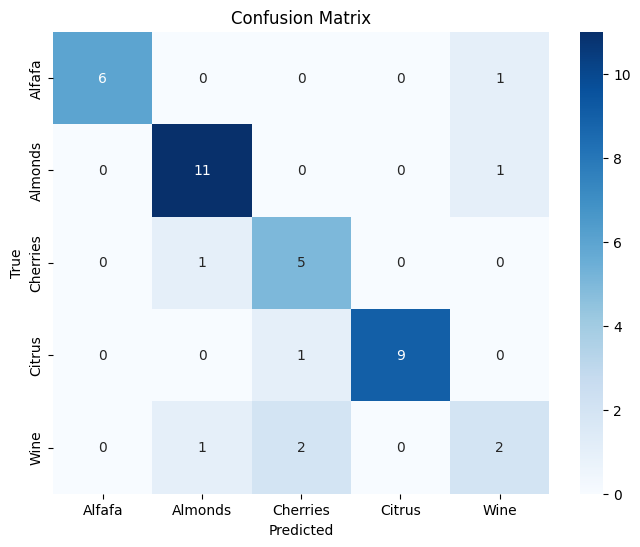

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Ensemble Models

Averaging the predictions of multiple independently trained models into a single prediction is a common approach to building a better final model by decreasing the variance of the predictions. In traditional ensemble methods, all base classifiers belong to a certain type of algorithm. For example, in a random forest, all base classifiers are decision trees. However, using a single type of algorithm limits the advantages and disadvantages of the final model to those of the base classifier. On the other hand, using multiple types of algorithms allows learning a more diverse representation of the data. In particular, for time series classification, ensemble models that combine different types of algorithms (bag-of-words approaches, shapelet-based algorithms, convolutions, etc.) have been developed. They are usually state-of-the-art in terms of predictive performance, at the cost of high computational complexity.

The Collective of Transformation-Based Ensembles (COTE) algorithm was the first proposed ensemble classifier. The most effective ensemble strategy was found to combine all classifiers into a flat hierarchy, and the corresponding model is often referred to as Flat-COTE. Flat-COTE combines 35 classifiers on four data representations: 11 classifiers based on integer series similarity measures, 8 shapelet-transform based classifiers, 8 based on autocorrelation features, and 8 based on power spectrum.

The Hierarchical Vote Collective of Transformation-Based Ensembles (HIVE-COTE) algorithm is an extension of COTE with significant modifications, including a new type of spectral classifier called Random Interval Spectral Ensemble, two more classifiers (BOSS and Time Series Forest), and a hierarchical voting procedure, defined as a weighted average of the probabilities returned by each classifier, with the weights being proportional to the classification accuracy estimated through cross-validation.

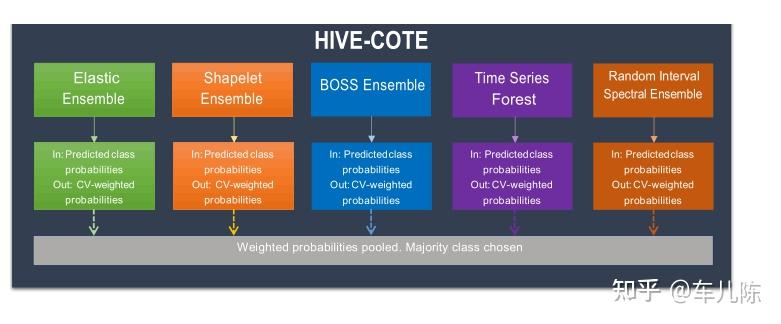

In [ ]:
from sktime.classification.hybrid import HIVECOTEV2
hc2 = HIVECOTEV2(time_limit_in_minutes=0.2)
hc2.fit(X_train, y_train)

In [ ]:
y_pred = hc2.predict(X_test)
accuracy_score(y_test, y_pred)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()